### About this code
This implementation develops and evaluates an incremental shortest-path framework for dynamic weighted graphs. The workflow begins by generating synthetic grid-based networks with varying levels of connectivity, followed by the computation of baseline shortest paths using Dijkstra’s algorithm. It then introduces an incremental repair algorithm that efficiently updates shortest paths after edge-weight modifications by recomputing only the affected portion of the network. A comprehensive experimental study evaluates the algorithm across varying graph sizes, network redundancy levels, update magnitudes, batch sizes, and spatial update distributions. Performance is compared against full Dijkstra recomputation using metrics including affected vertices, node expansions, edge relaxations, predecessor scans, execution time, and computational savings. Finally, the aggregated results are visualized through publication-quality figures, demonstrating the scalability of the incremental approach, the conditions under which it outperforms full recomputation, the benefits of predecessor caching, and the influence of update placement on repair efficiency.

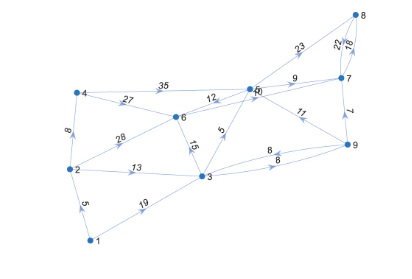

***

### Code Block I

In [ ]:
"""
Dynamic Dijkstra experiments E1-E4.

E1a: repair cost vs affected-region size, across network redundancy
E1b: does cost-per-affected-vertex stay flat as |V| grows?
E2:  are weight increases more expensive than decreases?
E3:  where does incremental repair stop beating full recomputation?
E4:  does batching help more when updates are spatially clustered?


"""

import heapq
import random
import csv
import time
from collections import defaultdict
import os



INF = float('inf')



# Graph construction

def build_grid(n, seed=0, wmin=1.0, wmax=10.0, obstacle_density=0.0):
    """
    n x n grid, 4-neighbour, directed edges both ways with independent weights.
    obstacle_density removes that fraction of undirected links (both directions),
    which creates bottlenecks and reduces route redundancy.
    """
    rng = random.Random(seed)
    succ, pred, w = defaultdict(list), defaultdict(list), {}

    links = []
    for r in range(n):
        for c in range(n):
            u = r * n + c
            if c + 1 < n:
                links.append((u, r * n + c + 1))
            if r + 1 < n:
                links.append((u, (r + 1) * n + c))

    rng.shuffle(links)
    for u, v in links[int(len(links) * obstacle_density):]:
        for a, b in ((u, v), (v, u)):
            w[(a, b)] = rng.uniform(wmin, wmax)
            succ[a].append(b)
            pred[b].append(a)

    return {'n': n, 'V': n * n, 'succ': succ, 'pred': pred, 'w': w,
            'density': obstacle_density}


def manhattan(G, u, v):
    n = G['n']
    return abs(u // n - v // n) + abs(u % n - v % n)


def depth_from_source(G, u):
    n = G['n']
    return (u // n) + (u % n)


# Baseline

def dijkstra(G, s):
    succ, w = G['succ'], G['w']
    dist = {v: INF for v in range(G['V'])}
    dist[s] = 0.0
    settled = relaxations = 0
    done = set()
    pq = [(0.0, s)]

    while pq:
        d, u = heapq.heappop(pq)
        if u in done:
            continue
        done.add(u)
        settled += 1
        for v in succ[u]:
            relaxations += 1
            nd = d + w[(u, v)]
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))

    return dist, settled, relaxations


# Incremental repair

class IncrementalSP:
    def __init__(self, G, s):
        self.G, self.s = G, s
        self.g = {v: INF for v in range(G['V'])}
        self.rhs = {v: INF for v in range(G['V'])}
        self.rhs[s] = 0.0
        self.U = []
        self.expansions = self.relaxations = 0
        heapq.heappush(self.U, (0.0, s))
        self.compute_shortest_path()

    def _key(self, v):
        return min(self.g[v], self.rhs[v])

    def update_vertex(self, v):
        if v != self.s:
            best = INF
            for u in self.G['pred'][v]:
                self.relaxations += 1
                cand = self.g[u] + self.G['w'][(u, v)]
                if cand < best:
                    best = cand
            self.rhs[v] = best
        if self.g[v] != self.rhs[v]:
            heapq.heappush(self.U, (self._key(v), v))

    def compute_shortest_path(self):
        while self.U:
            k, u = heapq.heappop(self.U)
            if self.g[u] == self.rhs[u]:
                continue
            if k != self._key(u):
                heapq.heappush(self.U, (self._key(u), u))
                continue
            self.expansions += 1
            if self.g[u] > self.rhs[u]:
                self.g[u] = self.rhs[u]
                for v in self.G['succ'][u]:
                    self.update_vertex(v)
            else:
                self.g[u] = INF
                self.update_vertex(u)
                for v in self.G['succ'][u]:
                    self.update_vertex(v)

    def apply_batch(self, changes):
        """All weights applied first, then one repair pass."""
        self.expansions = self.relaxations = 0
        for (u, v), nw in changes:
            self.G['w'][(u, v)] = nw
            self.update_vertex(v)
        self.compute_shortest_path()
        return self.expansions, self.relaxations

    def apply_sequential(self, changes):
        """One edge at a time, full repair pass after each."""
        te = tr = 0
        for c in changes:
            e, r = self.apply_batch([c])
            te += e
            tr += r
        return te, tr

    def snapshot(self):
        return (dict(self.g), dict(self.rhs), dict(self.G['w']))

    def restore(self, snap):
        g, rhs, w = snap
        self.g = dict(g)
        self.rhs = dict(rhs)
        self.G['w'] = dict(w)
        self.U = []



# Helpers

def differs(a, b, tol=1e-9):
    if a == INF and b == INF:
        return False
    if a == INF or b == INF:
        return True
    return abs(a - b) > tol


def affected_count(before, after):
    return sum(1 for v in before if differs(before[v], after[v]))


def verify(G, sp, s):
    truth, _, _ = dijkstra(G, s)
    for v in range(G['V']):
        assert not differs(sp.g[v], truth[v], 1e-6), \
            f"mismatch at {v}: {sp.g[v]} vs {truth[v]}"


def reachable_count(dist):
    return sum(1 for d in dist.values() if d < INF)


def median(xs):
    xs = sorted(xs)
    return xs[len(xs) // 2] if xs else 0


def write_csv(name, rows):
    if not rows:
        return
    with open(name, 'w', newline='') as f:
        wri = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        wri.writeheader()
        wri.writerows(rows)


def random_live_edge(G, rng):
    for _ in range(2000):
        u = rng.randrange(G['V'])
        if G['succ'][u]:
            return (u, rng.choice(G['succ'][u]))
    raise RuntimeError("no live edges found")


def edge_at_depth(G, rng, target, tol=4):
    for _ in range(800):
        u = rng.randrange(G['V'])
        if G['succ'][u] and abs(depth_from_source(G, u) - target) <= tol:
            return (u, rng.choice(G['succ'][u]))
    return random_live_edge(G, rng)


def build_usable_grid(n, seed, density, min_reachable=0.90, max_tries=25):
    """
    Rebuild with a fresh seed until the source is connected to most of the grid.
    Without this, obstacles can isolate the top-left corner and every update
    then appears to change nothing.
    """
    for attempt in range(max_tries):
        G = build_grid(n, seed=seed + attempt * 1000, obstacle_density=density)
        if not G['succ'][0]:
            continue
        dist, settled, _ = dijkstra(G, 0)
        reach = reachable_count(dist)
        if reach >= min_reachable * G['V']:
            return G, reach, settled
    raise RuntimeError(f"could not build a usable {n}x{n} grid at density {density}")



# E1a: cost vs affected size, swept over network redundancy

def run_e1a(n=100, densities=(0.0, 0.1, 0.2, 0.3, 0.4), trials=80, seed=11):
    rows = []
    print(f"[E1a] grid {n}x{n}, sweeping obstacle density")

    for dens in densities:
        rng = random.Random(seed + int(dens * 100))
        G, reach, base_settled = build_usable_grid(n, seed + int(dens * 100),
                                                   dens, min_reachable=0.85)
        s = 0
        sp = IncrementalSP(G, s)
        max_depth = 2 * (n - 1)

        for t in range(trials):
            depth = int(max_depth * (t + 0.5) / trials)
            e = edge_at_depth(G, rng, depth)
            old_w = G['w'][e]

            before = dict(sp.g)
            exp, rel = sp.apply_batch([(e, old_w * rng.uniform(2.0, 6.0))])
            aff = affected_count(before, dict(sp.g))

            rows.append({
                'density': dens, 'grid_n': n, 'V': G['V'], 'reachable': reach,
                'trial': t, 'edge_depth': depth, 'affected': aff,
                'inc_expansions': exp, 'inc_relaxations': rel,
                'full_settled': base_settled,
            })

            G['w'][e] = old_w
            sp.update_vertex(e[1])
            sp.compute_shortest_path()

            if t % 20 == 0:
                verify(G, sp, s)

        verify(G, sp, s)
        sub = [r for r in rows if r['density'] == dens and r['affected'] > 0]
        affs = [r['affected'] for r in sub]
        print(f"  density {dens:.1f}: reachable {reach}/{G['V']}, "
              f"{len(sub)}/{trials} non-trivial, "
              f"affected median {median(affs)}, max {max(affs) if affs else 0}")

    write_csv('e1a_results.csv', rows)

    print(f"\n[E1a] summary")
    print(f"{'density':>8} {'med aff':>9} {'max aff':>9} {'med exp':>9} "
          f"{'med exp/aff':>12} {'full settled':>13}")
    for dens in densities:
        sub = [r for r in rows if r['density'] == dens and r['affected'] > 0]
        if not sub:
            continue
        print(f"{dens:>8.1f} {median([r['affected'] for r in sub]):>9} "
              f"{max(r['affected'] for r in sub):>9} "
              f"{median([r['inc_expansions'] for r in sub]):>9} "
              f"{median([r['inc_expansions'] / r['affected'] for r in sub]):>12.2f} "
              f"{sub[0]['full_settled']:>13}")
    return rows



# E1b: does cost-per-affected-vertex stay flat as |V| grows?


def run_e1b(sizes=(60, 100, 150, 200), density=0.3,
            instances=5, trials=60, seed=21):
    rows = []
    print(f"[E1b] obstacle density {density}, {instances} graph instances "
          f"per size, {trials} trials each")

    for n in sizes:
        for inst in range(instances):
            G, reach, settled = build_usable_grid(n, seed + n * 7 + inst * 131,
                                                  density)
            rng = random.Random(seed + n + inst)
            s = 0
            sp = IncrementalSP(G, s)
            max_depth = 2 * (n - 1)

            for t in range(trials):
                depth = int(max_depth * (t + 0.5) / trials)
                e = edge_at_depth(G, rng, depth)
                old_w = G['w'][e]

                before = dict(sp.g)
                exp, rel = sp.apply_batch([(e, old_w * rng.uniform(2.0, 6.0))])
                aff = affected_count(before, dict(sp.g))

                rows.append({
                    'grid_n': n, 'V': G['V'], 'instance': inst, 'trial': t,
                    'reachable': reach, 'affected': aff,
                    'inc_expansions': exp, 'inc_relaxations': rel,
                    'full_settled': settled,
                })

                G['w'][e] = old_w
                sp.update_vertex(e[1])
                sp.compute_shortest_path()

            verify(G, sp, s)

        sub = [r for r in rows if r['grid_n'] == n and r['affected'] > 0]
        print(f"  {n}x{n}: |V|={n*n}, {len(sub)} non-trivial trials "
              f"out of {instances * trials}")

    write_csv('e1b_results.csv', rows)

    print(f"\n[E1b] summary (trials where the update changed something)")
    print(f"{'grid':>6} {'|V|':>8} {'n':>6} {'med aff':>9} {'max aff':>9} "
          f"{'med exp':>9} {'med exp/aff':>12} {'aff % of V':>12}")
    for n in sizes:
        sub = [r for r in rows if r['grid_n'] == n and r['affected'] > 0]
        if not sub:
            print(f"{n:>6}  no non-trivial trials")
            continue
        ma = median([r['affected'] for r in sub])
        print(f"{n:>6} {sub[0]['V']:>8} {len(sub):>6} {ma:>9} "
              f"{max(r['affected'] for r in sub):>9} "
              f"{median([r['inc_expansions'] for r in sub]):>9} "
              f"{median([r['inc_expansions'] / r['affected'] for r in sub]):>12.2f} "
              f"{100.0 * ma / sub[0]['V']:>11.3f}%")

    print(f"\n[E1b] cost relative to full recomputation")
    print(f"{'grid':>6} {'|V|':>8} {'med inc exp':>12} {'med full':>10} "
          f"{'saving':>10}")
    for n in sizes:
        sub = [r for r in rows if r['grid_n'] == n and r['affected'] > 0]
        if not sub:
            continue
        mi = median([r['inc_expansions'] for r in sub])
        mf = median([r['full_settled'] for r in sub])
        print(f"{n:>6} {sub[0]['V']:>8} {mi:>12} {mf:>10} "
              f"{mf / mi if mi else 0:>9.0f}x")
    return rows



# E2: increase vs decrease


def run_e2(n=100, densities=(0.0, 0.3), trials=80, seed=31):
    rows = []
    print(f"[E2] grid {n}x{n}, increase vs decrease")

    for dens in densities:
        rng = random.Random(seed + int(dens * 100))
        G, reach, _ = build_usable_grid(n, seed + int(dens * 100), dens,
                                        min_reachable=0.85)
        s = 0
        sp = IncrementalSP(G, s)
        max_depth = 2 * (n - 1)

        for t in range(trials):
            depth = int(max_depth * (t + 0.5) / trials)
            e = edge_at_depth(G, rng, depth)
            old_w = G['w'][e]

            for direction, factor in (('increase', rng.uniform(2.0, 6.0)),
                                      ('decrease', rng.uniform(0.15, 0.5))):
                before = dict(sp.g)
                exp, rel = sp.apply_batch([(e, old_w * factor)])
                aff = affected_count(before, dict(sp.g))

                rows.append({
                    'density': dens, 'trial': t, 'direction': direction,
                    'affected': aff, 'inc_expansions': exp,
                    'inc_relaxations': rel,
                    'exp_per_affected': (exp / aff) if aff else 0.0,
                    'relax_per_affected': (rel / aff) if aff else 0.0,
                })

                G['w'][e] = old_w
                sp.update_vertex(e[1])
                sp.compute_shortest_path()

        verify(G, sp, s)

    write_csv('e2_results.csv', rows)

    print(f"\n{'density':>8} {'direction':>10} {'med aff':>9} {'med exp':>9} "
          f"{'med exp/aff':>12} {'med relax':>11} {'relax/aff':>11}")
    for dens in densities:
        for d in ('increase', 'decrease'):
            sub = [r for r in rows if r['density'] == dens
                   and r['direction'] == d and r['affected'] > 0]
            if not sub:
                continue
            print(f"{dens:>8.1f} {d:>10} "
                  f"{median([r['affected'] for r in sub]):>9} "
                  f"{median([r['inc_expansions'] for r in sub]):>9} "
                  f"{median([r['exp_per_affected'] for r in sub]):>12.2f} "
                  f"{median([r['inc_relaxations'] for r in sub]):>11} "
                  f"{median([r['relax_per_affected'] for r in sub]):>11.1f}")

    for dens in densities:
        inc = [r['exp_per_affected'] for r in rows if r['density'] == dens
               and r['direction'] == 'increase' and r['affected'] > 0]
        dec = [r['exp_per_affected'] for r in rows if r['density'] == dens
               and r['direction'] == 'decrease' and r['affected'] > 0]
        if inc and dec:
            print(f"  density {dens:.1f}: increase/decrease ratio = "
                  f"{median(inc) / median(dec):.2f}")
    return rows



# E3: crossover against full recomputation


def run_e3(n=100, density=0.3, trials=20, seed=41):
    rows = []
    G0, _, _ = build_usable_grid(n, seed, density)
    n_edges = len(G0['w'])
    ks = [k for k in (1, 2, 5, 10, 25, 50, 100, 150, 200, 250, 500,
                      1000, 2000, 4000) if k <= n_edges // 2]

    print(f"[E3] grid {n}x{n}, density {density}, {n_edges} directed edges")

    for k in ks:
        rng = random.Random(seed + k)
        G, _, _ = build_usable_grid(n, seed, density)
        s = 0
        sp = IncrementalSP(G, s)
        snap = sp.snapshot()

        for t in range(trials):
            edges = [random_live_edge(G, rng) for _ in range(k)]
            changes = [(e, G['w'][e] * rng.uniform(2.0, 6.0)) for e in edges]

            before = dict(sp.g)
            t0 = time.perf_counter()
            exp, rel = sp.apply_batch(changes)
            t_inc = time.perf_counter() - t0
            aff = affected_count(before, dict(sp.g))

            t0 = time.perf_counter()
            _, settled, frelax = dijkstra(G, s)
            t_full = time.perf_counter() - t0

            rows.append({
                'k': k, 'trial': t, 'affected': aff,
                'inc_expansions': exp, 'inc_relaxations': rel,
                'full_settled': settled, 'full_relaxations': frelax,
                'ratio_exp': exp / settled if settled else 0.0,
                'inc_time': t_inc, 'full_time': t_full,
                'ratio_time': t_inc / t_full if t_full else 0.0,
            })

            sp.restore(snap)

        sub = [r for r in rows if r['k'] == k]
        print(f"  k={k:>5}: med affected {median([r['affected'] for r in sub]):>6}, "
              f"inc exp {median([r['inc_expansions'] for r in sub]):>6}, "
              f"full {sub[0]['full_settled']:>6}, "
              f"ratio {median([r['ratio_exp'] for r in sub]):.3f}")

    write_csv('e3_results.csv', rows)

    print(f"\n[E3] summary  (ratio < 1 means incremental wins)")
    print(f"{'k':>7} {'% edges':>9} {'med aff':>9} {'med inc exp':>12} "
          f"{'full':>8} {'ratio exp':>10} {'ratio time':>11} {'winner':>12}")
    for k in ks:
        sub = [r for r in rows if r['k'] == k]
        if not sub:
            continue
        ratio = median([r['ratio_exp'] for r in sub])
        print(f"{k:>7} {100.0 * k / n_edges:>8.2f}% "
              f"{median([r['affected'] for r in sub]):>9} "
              f"{median([r['inc_expansions'] for r in sub]):>12} "
              f"{sub[0]['full_settled']:>8} {ratio:>10.3f} "
              f"{median([r['ratio_time'] for r in sub]):>11.3f} "
              f"{'incremental' if ratio < 1 else 'full':>12}")
    return rows



# E4: batched vs sequential, clustered vs random


def clustered_edges(G, rng, k):
    """k edges near one random centre, imitating a contiguous traffic jam."""
    centre = rng.randrange(G['V'])
    cands = sorted((manhattan(G, u, centre), u)
                   for u in range(G['V']) if G['succ'][u])
    out = []
    for _, u in cands:
        for v in G['succ'][u]:
            out.append((u, v))
            if len(out) >= k:
                return out
    return out


def run_e4(n=100, density=0.3, ks=(10, 25, 50, 100, 200), trials=20, seed=51):
    rows = []
    print(f"[E4] grid {n}x{n}, density {density}, batched vs sequential")

    for k in ks:
        for mode in ('clustered', 'random'):
            rng = random.Random(seed + k + (0 if mode == 'clustered' else 999))
            G, _, _ = build_usable_grid(n, seed, density)
            s = 0
            sp = IncrementalSP(G, s)
            snap = sp.snapshot()

            for t in range(trials):
                edges = (clustered_edges(G, rng, k) if mode == 'clustered'
                         else [random_live_edge(G, rng) for _ in range(k)])
                changes = [(e, G['w'][e] * rng.uniform(2.0, 6.0)) for e in edges]

                b_exp, b_rel = sp.apply_batch(changes)
                sp.restore(snap)

                s_exp, s_rel = sp.apply_sequential(changes)
                sp.restore(snap)

                rows.append({
                    'k': k, 'mode': mode, 'trial': t,
                    'batched_exp': b_exp, 'sequential_exp': s_exp,
                    'batched_relax': b_rel, 'sequential_relax': s_rel,
                    'speedup': s_exp / b_exp if b_exp else 0.0,
                })

            sub = [r for r in rows if r['k'] == k and r['mode'] == mode]
            print(f"  k={k:>4} {mode:>10}: batched "
                  f"{median([r['batched_exp'] for r in sub]):>6}, sequential "
                  f"{median([r['sequential_exp'] for r in sub]):>7}, speedup "
                  f"{median([r['speedup'] for r in sub]):.2f}x")

    write_csv('e4_results.csv', rows)

    print(f"\n[E4] summary")
    print(f"{'k':>6} {'mode':>11} {'med batched':>12} {'med sequential':>15} "
          f"{'speedup':>9}")
    for k in ks:
        for mode in ('clustered', 'random'):
            sub = [r for r in rows if r['k'] == k and r['mode'] == mode]
            if not sub:
                continue
            print(f"{k:>6} {mode:>11} "
                  f"{median([r['batched_exp'] for r in sub]):>12} "
                  f"{median([r['sequential_exp'] for r in sub]):>15} "
                  f"{median([r['speedup'] for r in sub]):>8.2f}x")
    return rows



RUN = {'e1a': True, 'e1b': True, 'e2': True, 'e3': True, 'e4': True}

if __name__ == '__main__':
    t_start = time.perf_counter()
    for name, fn in (('e1a', run_e1a), ('e1b', run_e1b), ('e2', run_e2),
                     ('e3', run_e3), ('e4', run_e4)):
        if RUN.get(name):
            print("=" * 74)
            fn()
    print("=" * 74)
    print(f"\nDone in {time.perf_counter() - t_start:.1f}s. "
          f"Wrote CSVs for the experiments that ran.")

[E1a] grid 100x100, sweeping obstacle density
  density 0.0: reachable 10000/10000, 18/80 non-trivial, affected median 2, max 218
  density 0.1: reachable 9999/10000, 25/80 non-trivial, affected median 4, max 4562
  density 0.2: reachable 9974/10000, 29/80 non-trivial, affected median 2, max 273
  density 0.3: reachable 9857/10000, 27/80 non-trivial, affected median 2, max 1207
  density 0.4: reachable 9363/10000, 27/80 non-trivial, affected median 6, max 9347

[E1a] summary
 density   med aff   max aff   med exp  med exp/aff  full settled
     0.0         2       218         4         2.00         10000
     0.1         4      4562         8         2.00          9999
     0.2         2       273         4         2.00          9974
     0.3         2      1207         4         2.00          9857
     0.4         6      9347        12         2.00          9363
[E1b] obstacle density 0.3, 5 graph instances per size, 60 trials each
  60x60: |V|=3600, 89 non-trivial trials out of 300
 

***

## Code Block II

In [ ]:

"""
E6: how much does update placement matter?

The clustered numbers in E5b came from a single graph and a single seed
per k, so this re-runs the clustered/random comparison at matched batch
sizes across several graph instances, and reports spread rather than
just medians.

"""

INF = float('inf')


# Graph


def build_grid(n, seed=0, wmin=1.0, wmax=10.0, obstacle_density=0.0):
    rng = random.Random(seed)
    succ, pred, w = defaultdict(list), defaultdict(list), {}
    links = []
    for r in range(n):
        for c in range(n):
            u = r * n + c
            if c + 1 < n:
                links.append((u, r * n + c + 1))
            if r + 1 < n:
                links.append((u, (r + 1) * n + c))
    rng.shuffle(links)
    for u, v in links[int(len(links) * obstacle_density):]:
        for a, b in ((u, v), (v, u)):
            w[(a, b)] = rng.uniform(wmin, wmax)
            succ[a].append(b)
            pred[b].append(a)
    return {'n': n, 'V': n * n, 'succ': succ, 'pred': pred, 'w': w}


def dijkstra(G, s):
    succ, w = G['succ'], G['w']
    dist = {v: INF for v in range(G['V'])}
    dist[s] = 0.0
    settled = scans = 0
    done = set()
    pq = [(0.0, s)]
    while pq:
        d, u = heapq.heappop(pq)
        if u in done:
            continue
        done.add(u)
        settled += 1
        for v in succ[u]:
            scans += 1
            nd = d + w[(u, v)]
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist, settled, scans


def build_usable_grid(n, seed, density, min_reachable=0.90, max_tries=30):
    for attempt in range(max_tries):
        G = build_grid(n, seed=seed + attempt * 1000, obstacle_density=density)
        if not G['succ'][0]:
            continue
        dist, settled, _ = dijkstra(G, 0)
        if sum(1 for d in dist.values() if d < INF) >= min_reachable * G['V']:
            return G, settled
    raise RuntimeError(f"no usable {n}x{n} grid at density {density}")



# Cached incremental repair (the variant from E5)


class CachedSP:
    def __init__(self, G, s):
        self.G, self.s = G, s
        self.g = {v: INF for v in range(G['V'])}
        self.rhs = {v: INF for v in range(G['V'])}
        self.parent = {v: None for v in range(G['V'])}
        self.rhs[s] = 0.0
        self.U = []
        self.expansions = self.scans = 0
        heapq.heappush(self.U, (0.0, s))
        self.compute_shortest_path()

    def _key(self, v):
        return min(self.g[v], self.rhs[v])

    def _requeue(self, v):
        if self.g[v] != self.rhs[v]:
            heapq.heappush(self.U, (self._key(v), v))

    def recompute(self, v):
        if v == self.s:
            self.rhs[v] = 0.0
            self.parent[v] = None
            return
        best, bp = INF, None
        for u in self.G['pred'][v]:
            self.scans += 1
            c = self.g[u] + self.G['w'][(u, v)]
            if c < best:
                best, bp = c, u
        self.rhs[v] = best
        self.parent[v] = bp

    def offer(self, v, u):
        if v == self.s:
            return
        self.scans += 1
        c = self.g[u] + self.G['w'][(u, v)]
        if c < self.rhs[v]:
            self.rhs[v] = c
            self.parent[v] = u

    def compute_shortest_path(self):
        while self.U:
            k, u = heapq.heappop(self.U)
            if self.g[u] == self.rhs[u]:
                continue
            if k != self._key(u):
                heapq.heappush(self.U, (self._key(u), u))
                continue
            self.expansions += 1
            if self.g[u] > self.rhs[u]:
                self.g[u] = self.rhs[u]
                for v in self.G['succ'][u]:
                    self.offer(v, u)
                    self._requeue(v)
            else:
                self.g[u] = INF
                self.recompute(u)
                self._requeue(u)
                for v in self.G['succ'][u]:
                    if self.parent[v] == u:
                        self.recompute(v)
                    self._requeue(v)

    def apply_batch(self, changes):
        self.expansions = self.scans = 0
        for (u, v), nw in changes:
            old = self.G['w'][(u, v)]
            self.G['w'][(u, v)] = nw
            if v == self.s:
                continue
            if nw < old:
                self.offer(v, u)
                self._requeue(v)
            elif self.parent[v] == u:
                self.recompute(v)
                self._requeue(v)
        self.compute_shortest_path()
        return self.expansions, self.scans

    def snapshot(self):
        return (dict(self.g), dict(self.rhs), dict(self.parent), dict(self.G['w']))

    def restore(self, snap):
        g, rhs, par, w = snap
        self.g, self.rhs, self.parent = dict(g), dict(rhs), dict(par)
        self.G['w'] = dict(w)
        self.U = []



# Helpers


def differs(a, b, tol=1e-9):
    if a == INF and b == INF:
        return False
    if a == INF or b == INF:
        return True
    return abs(a - b) > tol


def quantile(xs, q):
    xs = sorted(xs)
    if not xs:
        return 0.0
    i = int(q * (len(xs) - 1))
    return xs[i]


def median(xs):
    return quantile(xs, 0.5)


def random_live_edge(G, rng):
    for _ in range(2000):
        u = rng.randrange(G['V'])
        if G['succ'][u]:
            return (u, rng.choice(G['succ'][u]))
    raise RuntimeError("no live edges")


def clustered_edges(G, rng, k):
    """k edges nearest one random centre, imitating a contiguous jam."""
    n = G['n']
    centre = rng.randrange(G['V'])
    cr, cc = centre // n, centre % n
    cands = sorted((abs(u // n - cr) + abs(u % n - cc), u)
                   for u in range(G['V']) if G['succ'][u])
    out = []
    for _, u in cands:
        for v in G['succ'][u]:
            out.append((u, v))
            if len(out) >= k:
                return out
    return out



# E6


def run_e6(n=100, density=0.3, instances=5, trials=15, seed=81,
           ks=(25, 50, 100, 150, 200, 300, 500)):
    rows = []
    print(f"[E6] grid {n}x{n}, density {density}, "
          f"{instances} graph instances, {trials} trials each")
    print(f"     clustered vs random placement at matched batch sizes\n")

    for inst in range(instances):
        G, full_settled = build_usable_grid(n, seed + inst * 977, density)
        n_edges = len(G['w'])
        s = 0
        sp = CachedSP(G, s)
        snap = sp.snapshot()

        for k in ks:
            if k > n_edges // 2:
                continue
            for mode in ('clustered', 'random'):
                rng = random.Random(seed + inst * 31 + k
                                    + (0 if mode == 'clustered' else 7919))
                for t in range(trials):
                    edges = (clustered_edges(G, rng, k) if mode == 'clustered'
                             else [random_live_edge(G, rng) for _ in range(k)])
                    changes = [(e, G['w'][e] * rng.uniform(2.0, 6.0))
                               for e in edges]

                    t0 = time.perf_counter()
                    exp, scans = sp.apply_batch(changes)
                    t_inc = time.perf_counter() - t0

                    t0 = time.perf_counter()
                    truth, settled, d_scans = dijkstra(G, s)
                    t_full = time.perf_counter() - t0

                    for v in range(G['V']):
                        assert not differs(sp.g[v], truth[v], 1e-6), \
                            f"wrong distance at {v}"

                    rows.append({
                        'instance': inst, 'k': k, 'mode': mode, 'trial': t,
                        'expansions': exp, 'scans': scans,
                        'full_settled': settled, 'full_scans': d_scans,
                        'inc_time': t_inc, 'full_time': t_full,
                        'time_ratio': t_inc / t_full if t_full else 0.0,
                        'wins': 1 if t_inc < t_full else 0,
                    })

                    sp.restore(snap)

        print(f"  instance {inst}: done ({n_edges} edges, "
              f"full Dijkstra settles {full_settled})")

    with open('e6_results.csv', 'w', newline='') as f:
        wri = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        wri.writeheader()
        wri.writerows(rows)

    print(f"\n[E6] time relative to full Dijkstra, pooled over "
          f"{instances} instances")
    print(f"{'k':>6} {'mode':>11} {'n':>5} {'median':>9} {'q1':>9} {'q3':>9} "
          f"{'win rate':>10}")
    for k in ks:
        for mode in ('clustered', 'random'):
            sub = [r for r in rows if r['k'] == k and r['mode'] == mode]
            if not sub:
                continue
            rat = [r['time_ratio'] for r in sub]
            print(f"{k:>6} {mode:>11} {len(sub):>5} {median(rat):>9.3f} "
                  f"{quantile(rat, 0.25):>9.3f} {quantile(rat, 0.75):>9.3f} "
                  f"{100.0 * sum(r['wins'] for r in sub) / len(sub):>9.0f}%")

    print(f"\n[E6] placement effect at matched k")
    print(f"{'k':>6} {'clustered':>11} {'random':>10} {'ratio':>9} "
          f"{'clustered exp':>15} {'random exp':>12}")
    for k in ks:
        c = [r for r in rows if r['k'] == k and r['mode'] == 'clustered']
        r_ = [r for r in rows if r['k'] == k and r['mode'] == 'random']
        if not c or not r_:
            continue
        mc = median([x['time_ratio'] for x in c])
        mr = median([x['time_ratio'] for x in r_])
        print(f"{k:>6} {mc:>11.3f} {mr:>10.3f} {mr / mc if mc else 0:>8.1f}x "
              f"{median([x['expansions'] for x in c]):>15} "
              f"{median([x['expansions'] for x in r_]):>12}")

    print(f"\n[E6] crossover: largest k where the incremental method still wins")
    for mode in ('clustered', 'random'):
        best = None
        for k in ks:
            sub = [r for r in rows if r['k'] == k and r['mode'] == mode]
            if sub and median([x['time_ratio'] for x in sub]) < 1.0:
                best = k
        print(f"  {mode:>10}: k = {best if best else 'none tested'}")
    return rows


if __name__ == '__main__':
    t0 = time.perf_counter()
    print("=" * 74)
    run_e6()
    print("=" * 74)
    print(f"\nDone in {time.perf_counter() - t0:.1f}s. Wrote e6_results.csv")

[E6] grid 100x100, density 0.3, 5 graph instances, 15 trials each
     clustered vs random placement at matched batch sizes

  instance 0: done (27720 edges, full Dijkstra settles 9876)
  instance 1: done (27720 edges, full Dijkstra settles 9870)
  instance 2: done (27720 edges, full Dijkstra settles 9867)
  instance 3: done (27720 edges, full Dijkstra settles 9892)
  instance 4: done (27720 edges, full Dijkstra settles 9847)

[E6] time relative to full Dijkstra, pooled over 5 instances
     k        mode     n    median        q1        q3   win rate
    25   clustered    75     0.023     0.010     0.123        97%
    25      random    75     0.199     0.033     0.564        85%
    50   clustered    75     0.062     0.026     0.235        95%
    50      random    75     0.406     0.161     1.053        72%
   100   clustered    75     0.091     0.042     0.347        91%
   100      random    75     1.151     0.636     1.827        47%
   150   clustered    75     0.212     0.088  

***

### Code Block III

In [ ]:
"""
Generate figures from the experiment CSVs.
"""

try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
except ImportError:
    raise SystemExit("matplotlib is needed: pip install matplotlib")

DPI = 200
GREY = '#555555'


def load(name):
    if not os.path.exists(name):
        print(f"  skipping {name} (not found)")
        return None
    with open(name) as f:
        rows = list(csv.DictReader(f))
    for r in rows:
        for k, v in r.items():
            try:
                r[k] = float(v)
            except (ValueError, TypeError):
                pass
    print(f"  loaded {name} ({len(rows)} rows)")
    return rows

def median(xs):
    xs = sorted(xs)
    return xs[len(xs) // 2] if xs else 0

# Figure 1

def fig1(e1a, e1b):
    if not e1a and not e1b:
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) scatter: expansions vs affected region
    ax = axes[0]
    if e1a:
        by_dens = defaultdict(list)
        for r in e1a:
            if r['affected'] > 0:
                by_dens[r['density']].append((r['affected'], r['inc_expansions']))
        for dens in sorted(by_dens):
            pts = by_dens[dens]
            ax.scatter([p[0] for p in pts], [p[1] for p in pts],
                       s=18, alpha=0.6, label=f"density {dens:.1f}")
        lo = min(p[0] for pts in by_dens.values() for p in pts)
        hi = max(p[0] for pts in by_dens.values() for p in pts)
        ax.plot([lo, hi], [2 * lo, 2 * hi], '--', color=GREY,
                lw=1.2, label='slope 2 (predicted)')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('vertices whose distance changed')
        ax.set_ylabel('vertices expanded')
        ax.set_title('(a) Cost tracks the affected region')
        ax.legend(fontsize=8, frameon=False, loc='upper left')
        ax.grid(alpha=0.25, which='both')

    # (b) saving factor vs graph size
    ax = axes[1]
    if e1b:
        by_size = defaultdict(list)
        for r in e1b:
            if r['affected'] > 0 and r['inc_expansions'] > 0:
                by_size[int(r['V'])].append(
                    r['full_settled'] / r['inc_expansions'])
        sizes = sorted(by_size)
        savings = [median(by_size[s]) for s in sizes]
        ax.plot(sizes, savings, 'o-', color='#1f77b4', lw=1.8, ms=8)
        for s, v in zip(sizes, savings):
            ax.annotate(f"{v:,.0f}x", (s, v), textcoords='offset points',
                        xytext=(0, 9), ha='center', fontsize=8.5)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('graph size |V|')
        ax.set_ylabel('full Dijkstra cost / repair cost')
        ax.set_title('(b) Saving grows because the baseline does')
        ax.grid(alpha=0.25, which='both')
        ax.set_ylim(min(savings) * 0.45, max(savings) * 2.6)

    fig.tight_layout()
    fig.savefig('fig1_affected_scaling.png', dpi=DPI)
    plt.close(fig)
    print("  wrote fig1_affected_scaling.png")

# Figure 2


def fig2(e3, e6):
    if not e3 and not e6:
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    ax = axes[0]
    if e3:
        by_k = defaultdict(list)
        for r in e3:
            by_k[r['k']].append(r)
        ks = sorted(by_k)
        ax.plot(ks, [median([x['ratio_exp'] for x in by_k[k]]) for k in ks],
                'o-', lw=1.6, ms=6, label='operation count')
        if 'ratio_time' in e3[0]:
            ax.plot(ks, [median([x['ratio_time'] for x in by_k[k]]) for k in ks],
                    's-', lw=1.6, ms=6, label='wall clock')
        ax.axhline(1.0, ls='--', color=GREY, lw=1.2)
        ax.text(ks[0] * 1.1, 1.25, 'full recomputation cheaper above',
                fontsize=7.5, color=GREY)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('edges changed per batch (k)')
        ax.set_ylabel('cost relative to full Dijkstra')
        ax.set_title('(a) The two metrics disagree')
        ax.legend(fontsize=8, frameon=False, loc='lower right')
        ax.grid(alpha=0.25, which='both')

    ax = axes[1]
    if e6:
        for mode, mark, col in (('clustered', 'o', '#2ca02c'),
                                ('random', 's', '#d62728')):
            by_k = defaultdict(list)
            for r in e6:
                if r['mode'] == mode:
                    by_k[r['k']].append(r['time_ratio'])
            ks = sorted(by_k)
            ax.plot(ks, [median(by_k[k]) for k in ks], mark + '-',
                    color=col, lw=1.8, ms=7, label=mode)
        ax.axhline(1.0, ls='--', color=GREY, lw=1.2)
        ax.text(ks[0] * 1.05, 1.25, 'full recomputation cheaper above',
                fontsize=7.5, color=GREY)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('edges changed per batch (k)')
        ax.set_ylabel('wall clock relative to full Dijkstra')
        ax.set_title('(b) Update placement moves the crossover')
        ax.legend(fontsize=9, frameon=False, loc='lower right')
        ax.grid(alpha=0.25, which='both')

    fig.tight_layout()
    fig.savefig('fig2_crossover.png', dpi=DPI)
    plt.close(fig)
    print("  wrote fig2_crossover.png")

# Figure 3


def fig3(e5):
    if not e5:
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    by_k = defaultdict(list)
    for r in e5:
        by_k[r['k']].append(r)

    # a batch size where the cached variant did no scans at all cannot be
    # drawn on a log axis, so drop it from panel (a)
    ks_scan = [k for k in sorted(by_k)
               if median([x['cached_scans'] for x in by_k[k]]) > 0
               and median([x['base_scans'] for x in by_k[k]]) > 0]
    ks_time = sorted(by_k)

    ax = axes[0]
    ax.plot(ks_scan, [median([x['base_scans'] for x in by_k[k]]) for k in ks_scan],
            'o-', lw=1.6, ms=6, label='baseline')
    ax.plot(ks_scan, [median([x['cached_scans'] for x in by_k[k]]) for k in ks_scan],
            's-', lw=1.6, ms=6, label='predecessor caching')
    ax.plot(ks_scan, [median([x['full_scans'] for x in by_k[k]]) for k in ks_scan],
            '--', color=GREY, lw=1.4, label='full Dijkstra')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('edges changed per batch (k)')
    ax.set_ylabel('predecessor scans')
    ax.set_title('(a) Caching roughly halves the scans')
    ax.legend(fontsize=8, frameon=False, loc='lower right')
    ax.grid(alpha=0.25, which='both')

    ax = axes[1]
    ax.plot(ks_time,
            [median([x['base_vs_full_time'] for x in by_k[k]]) for k in ks_time],
            'o-', lw=1.6, ms=6, label='baseline')
    ax.plot(ks_time,
            [median([x['cached_vs_full_time'] for x in by_k[k]]) for k in ks_time],
            's-', lw=1.6, ms=6, label='predecessor caching')
    ax.axhline(1.0, ls='--', color=GREY, lw=1.2)
    ax.text(ks_time[0] * 1.1, 1.4, 'full recomputation cheaper above',
            fontsize=7.5, color=GREY)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('edges changed per batch (k)')
    ax.set_ylabel('wall clock relative to full Dijkstra')
    ax.set_title('(b) But the crossover does not move')
    ax.legend(fontsize=8, frameon=False, loc='lower right')
    ax.grid(alpha=0.25, which='both')

    fig.tight_layout()
    fig.savefig('fig3_caching.png', dpi=DPI)
    plt.close(fig)
    print("  wrote fig3_caching.png")


# Figure 4

def fig4(e2):
    if not e2:
        return
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    densities = sorted({r['density'] for r in e2})
    width = 0.35
    xs = range(len(densities))

    for i, (d, col) in enumerate((('increase', '#d62728'),
                                  ('decrease', '#2ca02c'))):
        vals = []
        for dens in densities:
            sub = [r['exp_per_affected'] for r in e2
                   if r['density'] == dens and r['direction'] == d
                   and r['affected'] > 0]
            vals.append(median(sub))
        ax.bar([x + (i - 0.5) * width for x in xs], vals, width,
               label=d, color=col, alpha=0.85)
        for x, v in zip(xs, vals):
            ax.text(x + (i - 0.5) * width, v + 0.04, f"{v:.2f}",
                    ha='center', fontsize=8.5)

    ax.set_xticks(list(xs))
    ax.set_xticklabels([f"obstacle density {d:.1f}" for d in densities])
    ax.set_ylabel('expansions per affected vertex')
    ax.set_title('Increases cost exactly twice what decreases cost')
    ax.set_ylim(0, 2.6)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(alpha=0.25, axis='y')

    fig.tight_layout()
    fig.savefig('fig4_asymmetry.png', dpi=DPI)
    plt.close(fig)
    print("  wrote fig4_asymmetry.png")


if __name__ == '__main__':
    print("loading:")
    e1a = load('e1a_results.csv')
    e1b = load('e1b_results.csv')
    e2 = load('e2_results.csv')
    e3 = load('e3_results.csv')
    e5 = load('e5_results.csv')
    e6 = load('e6_results.csv')

    print("\nplotting:")
    fig1(e1a, e1b)
    fig2(e3, e6)
    fig3(e5)
    fig4(e2)
    print("\ndone")

loading:
  loaded e1a_results.csv (400 rows)
  loaded e1b_results.csv (1200 rows)
  loaded e2_results.csv (320 rows)
  loaded e3_results.csv (280 rows)
  loaded e5_results.csv (220 rows)
  loaded e6_results.csv (1050 rows)

plotting:
  wrote fig1_affected_scaling.png
  wrote fig2_crossover.png
  wrote fig3_caching.png
  wrote fig4_asymmetry.png

done


***

🪐